In [14]:
import torch
from torch.utils.data import Dataset
import cv2
import numpy as np
import os
import albumentations as A
from albumentations.pytorch import ToTensorV2

class DatasetLoader(Dataset):
    def __init__(self, img_dir, label_dir, depth_dir, transform=None):
        self.img_dir = img_dir
        self.label_dir = label_dir
        self.depth_dir = depth_dir  
        self.img_names = [f for f in os.listdir(img_dir) if f.endswith('.jpg')]
        self.transform = transform

    def __len__(self):
        return len(self.img_names)
    
    def gray_world_correction(self, img):
        avg_b = np.average(img[:, :, 0])
        avg_g = np.average(img[:, :, 1])
        avg_r = np.average(img[:, :, 2])
        avg_gray = (avg_b + avg_g + avg_r) / 3
        img[:, :, 0] = np.clip(img[:, :, 0] * (avg_gray / (avg_b + 1e-6)), 0, 255)
        img[:, :, 1] = np.clip(img[:, :, 1] * (avg_gray / (avg_g + 1e-6)), 0, 255)
        img[:, :, 2] = np.clip(img[:, :, 2] * (avg_gray / (avg_r + 1e-6)), 0, 255)
        return img.astype(np.uint8)

    def fill_depth_inpainting(self, depth_np, max_depth=10000.0):
        # Membuat mask untuk memisahkan piksel valid dan invalid (lubang)
        valid_mask = (depth_np > 0) & (depth_np < max_depth)
        
        # Algoritma cv2.inpaint memerlukan input gambar bertipe uint8 (0-255)
        depth_8u = np.clip((depth_np / max_depth) * 255.0, 0, 255).astype(np.uint8)
        
        # Masking untuk inpainting (nilai 255 menandakan area yang harus diisi)
        inpaint_mask = (~valid_mask).astype(np.uint8) * 255
        
        # Eksekusi inpainting dengan algoritma Navier-Stokes (INPAINT_NS)
        inpainted_8u = cv2.inpaint(depth_8u, inpaint_mask, inpaintRadius=3, flags=cv2.INPAINT_NS)
        
        # Denormalisasi kembali ke dimensi ruang float32
        inpainted_depth = (inpainted_8u.astype(np.float32) / 255.0) * max_depth
        
        # Hanya menimpa nilai yang kosong, mempertahankan nilai sensor asli yang valid
        final_depth = np.where(valid_mask, depth_np, inpainted_depth)
        return final_depth
    
    def __getitem__(self, idx):
        img_name = self.img_names[idx]
        depth_base_name = img_name.split('_png.rf')[0] 
        
        img_path = os.path.join(self.img_dir, img_name)
        image = cv2.imread(img_path)
        image = self.gray_world_correction(image)
        h, w, _ = image.shape

        label_name = img_name.replace('.jpg', '.txt')
        label_path = os.path.join(self.label_dir, label_name)
        
        bboxes = []
        class_ids = []
        class_id = 0 

        if os.path.exists(label_path):
            with open(label_path, 'r') as f:
                content = f.read().split()
                if len(content) >= 9:
                    class_id = int(content[0]) + 1
                    coords = np.array(content[1:9], dtype=np.float32).reshape(4, 2)
                    
                    x_coords = coords[:, 0]
                    y_coords = coords[:, 1]
                    xmin = np.clip(np.min(x_coords), 0.0, 1.0)
                    ymin = np.clip(np.min(y_coords), 0.0, 1.0)
                    xmax = np.clip(np.max(x_coords), 0.0, 1.0)
                    ymax = np.clip(np.max(y_coords), 0.0, 1.0)
                    
                    x_center = (xmin + xmax) / 2.0
                    y_center = (ymin + ymax) / 2.0
                    b_width = xmax - xmin
                    b_height = ymax - ymin
                    
                    if b_width > 0 and b_height > 0:
                        bboxes.append([x_center, y_center, b_width, b_height])
                        class_ids.append(class_id)

        depth_name = f"{depth_base_name}.npy"
        depth_path = os.path.join(self.depth_dir, depth_name)
        
        # Depth Raw
        if os.path.exists(depth_path):
            depth = np.load(depth_path)
            if len(depth.shape) == 3 and depth.shape[0] == 1:
                depth = depth.squeeze(0) 
            depth = depth.astype(np.float32)
        else:
            depth = np.zeros((h, w), dtype=np.float32)

        # Depth Impainting        
        # if os.path.exists(depth_path):
        #     depth = np.load(depth_path)
        #     if len(depth.shape) == 3 and depth.shape[0] == 1:
        #         depth = depth.squeeze(0) 
            
        #     # PANGGIL FUNGSI INPAINTING DISINI
        #     depth = self.fill_depth_inpainting(depth)
            
        #     depth = depth.astype(np.float32)
        # else:
        #     depth = np.zeros((h, w), dtype=np.float32)

        if self.transform:
            augmented = self.transform(
                image=image, 
                depth=depth, 
                bboxes=bboxes,
                class_labels=class_ids
            )
            image = augmented['image']
            depth = augmented['depth']
            bboxes = augmented['bboxes']
            class_ids = augmented['class_labels']

        if len(bboxes) > 0:
            final_bbox = np.array(bboxes[0], dtype=np.float32)
            final_class = class_ids[0]
        else:
            final_bbox = np.zeros(4, dtype=np.float32)
            final_class = 0

        if len(image.shape) == 3 and not torch.is_tensor(image):
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        if not torch.is_tensor(image):
            image = torch.tensor(image.transpose(2, 0, 1), dtype=torch.float32) / 255.0

        coords_tensor = torch.tensor(final_bbox, dtype=torch.float32)
        depth_tensor = depth.clone().detach().to(torch.float32).unsqueeze(0) if torch.is_tensor(depth) else torch.tensor(depth, dtype=torch.float32).unsqueeze(0)

        return {
            'image': image,
            'class_id': torch.tensor(final_class, dtype=torch.long), 
            'coords': coords_tensor,
            'depth': depth_tensor
        }
        
def transformsFeats(img_hw_size=(512, 256)):
    return A.Compose(
        [
            A.Resize(height=img_hw_size[0], width=img_hw_size[1]),
            # A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=15, p=0.5),
            A.HorizontalFlip(p=0.5),
            # A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1, p=0.5),
            # A.GaussNoise(var_limit=(10.0, 50.0), p=0.3),
            # A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
            ToTensorV2(),
        ],bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']),
            additional_targets={'depth': 'image'}
    )

In [15]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def visualize_loader_output(dataset, idx):
    # Ekstraksi data dari loader
    sample = dataset[idx]
    image_tensor = sample['image']
    coords = sample['coords'].numpy()
    class_id = sample['class_id'].item()
    
    # Transformasi tensor PyTorch [C, H, W] kembali ke format Numpy [H, W, C]
    # Representasi nilai dipertahankan dalam rentang [0, 1] agar kompatibel dengan matplotlib
    image_np = image_tensor.permute(1, 2, 0).numpy()
    h, w, _ = image_np.shape
    
    fig, ax = plt.subplots(1, 1, figsize=(8, 8))
    ax.imshow(image_np)
    
    # Ekstraksi koordinat format YOLO: (cx, cy, width, height) ternormalisasi [0, 1]
    cx, cy, bw, bh = coords
    
    # Denormalisasi koordinat absolut ke skala piksel resolusi gambar akhir
    cx_pixel = cx * w
    cy_pixel = cy * h
    bw_pixel = bw * w
    bh_pixel = bh * h
    
    # Pergeseran titik referensi sentral (cx, cy) ke sudut kiri atas (xmin, ymin)
    xmin = cx_pixel - (bw_pixel / 2.0)
    ymin = cy_pixel - (bh_pixel / 2.0)
    
    # Plotting bounding box jika anotasinya valid (bukan background)
    if class_id > 0 and bw > 0 and bh > 0:
        rect = patches.Rectangle(
            (xmin, ymin), bw_pixel, bh_pixel, 
            linewidth=2, edgecolor='red', facecolor='none'
        )
        ax.add_patch(rect)
        ax.set_title(f"Class ID: {class_id}\nYOLO [cx, cy, w, h]: [{cx:.3f}, {cy:.3f}, {bw:.3f}, {bh:.3f}]")
    else:
        ax.set_title("Status: Background / No Object Detected")
        
    ax.axis('off')
    plt.tight_layout()
    plt.show()

# --- Contoh Eksekusi ---
# Pastikan train_dataset sudah dideklarasikan sebelumnya
# visualize_loader_output(train_dataset, 0)

In [16]:
img_dir = 'Dataset/train/images' 
label_dir = 'Dataset/train/labels'
depth_dir = 'Dataset/train/depths'

loader = DatasetLoader(img_dir, label_dir, depth_dir, transform=transformsFeats(img_hw_size=(256, 256)))

In [17]:
ret = loader.__getitem__(0)
img, class_id, coord, depth = ret['image'], ret['class_id'], ret['coords'], ret['depth']
print("Image Shape:", img.shape)  # Should be (C, H, W
print("Class ID:", class_id.item())
print("Coords Shape:", coord.shape)  # Should be (8,)
print("Depth Shape:", depth.shape)  # Should be (1, H, W)

Image Shape: torch.Size([3, 256, 256])
Class ID: 1
Coords Shape: torch.Size([4])
Depth Shape: torch.Size([1, 1, 256, 256])


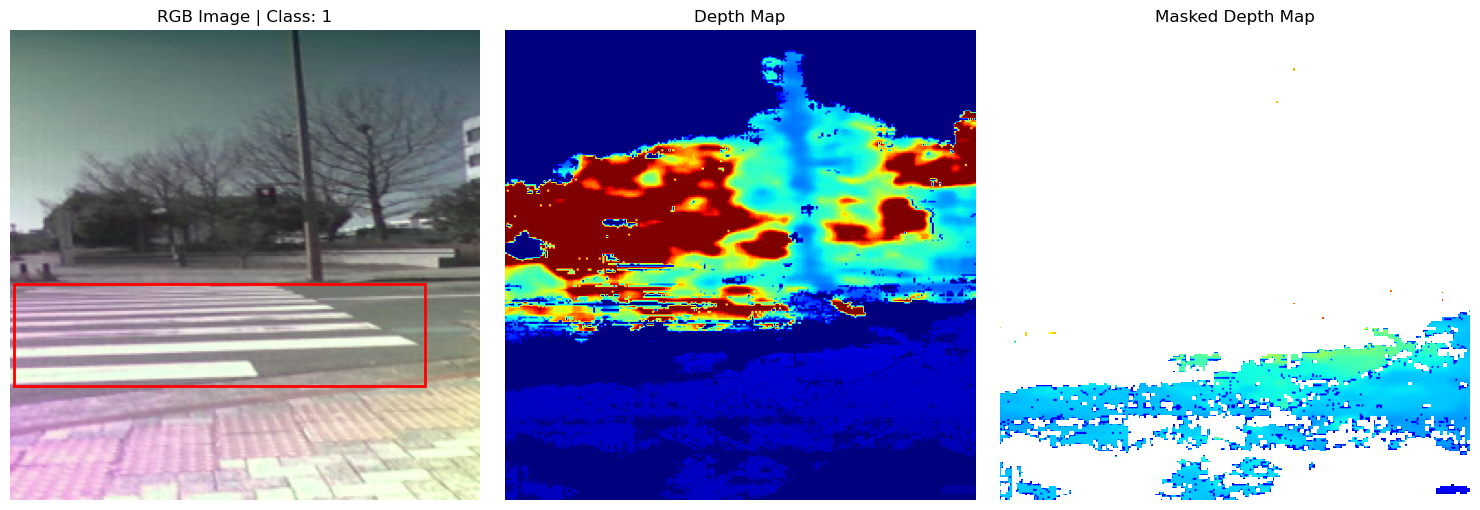

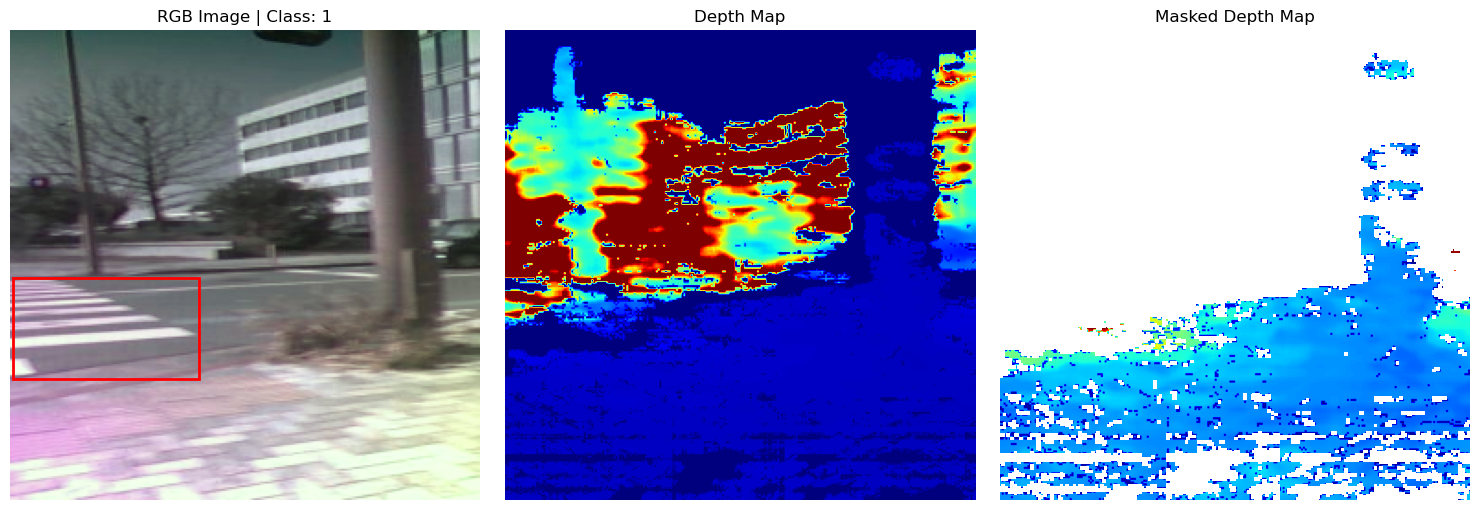

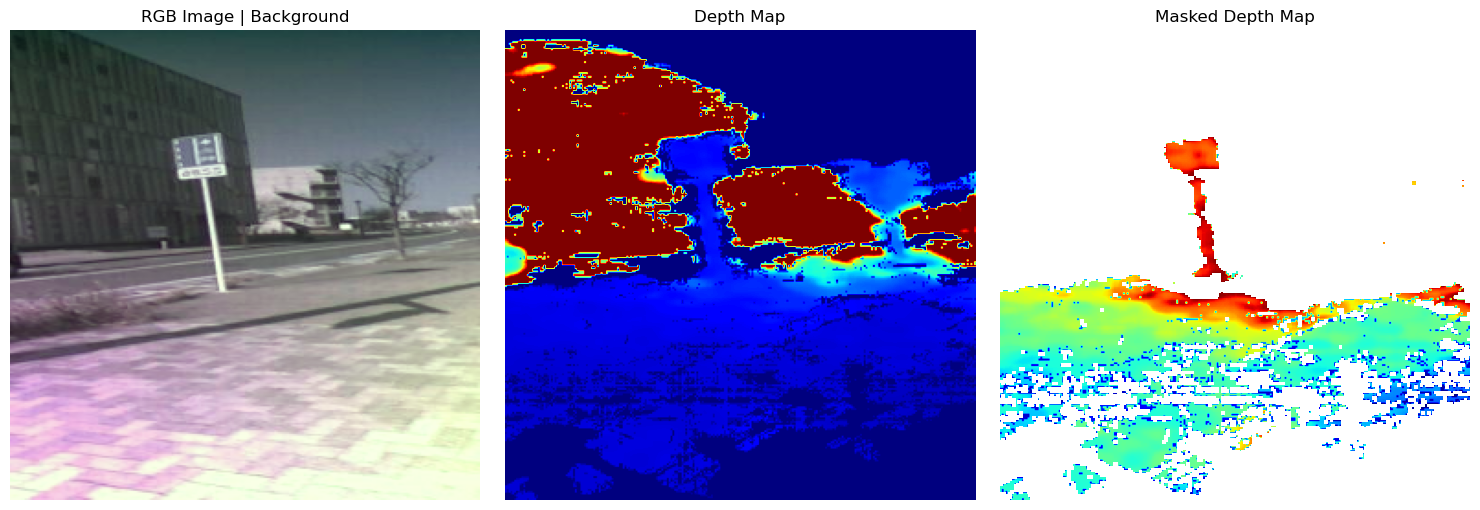

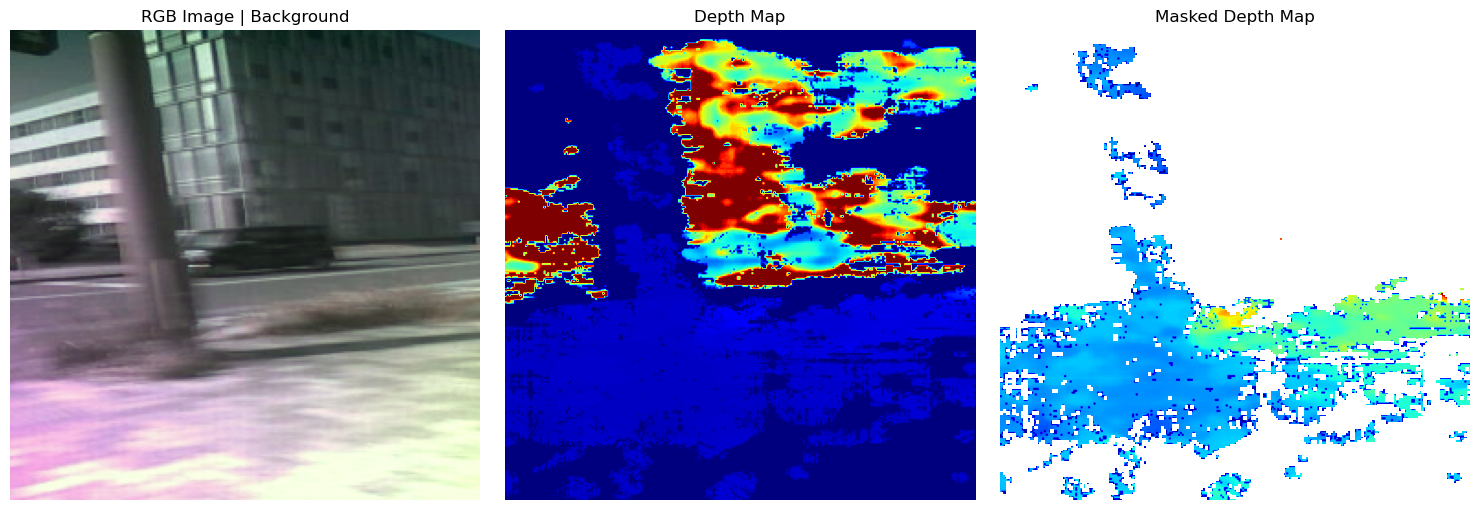

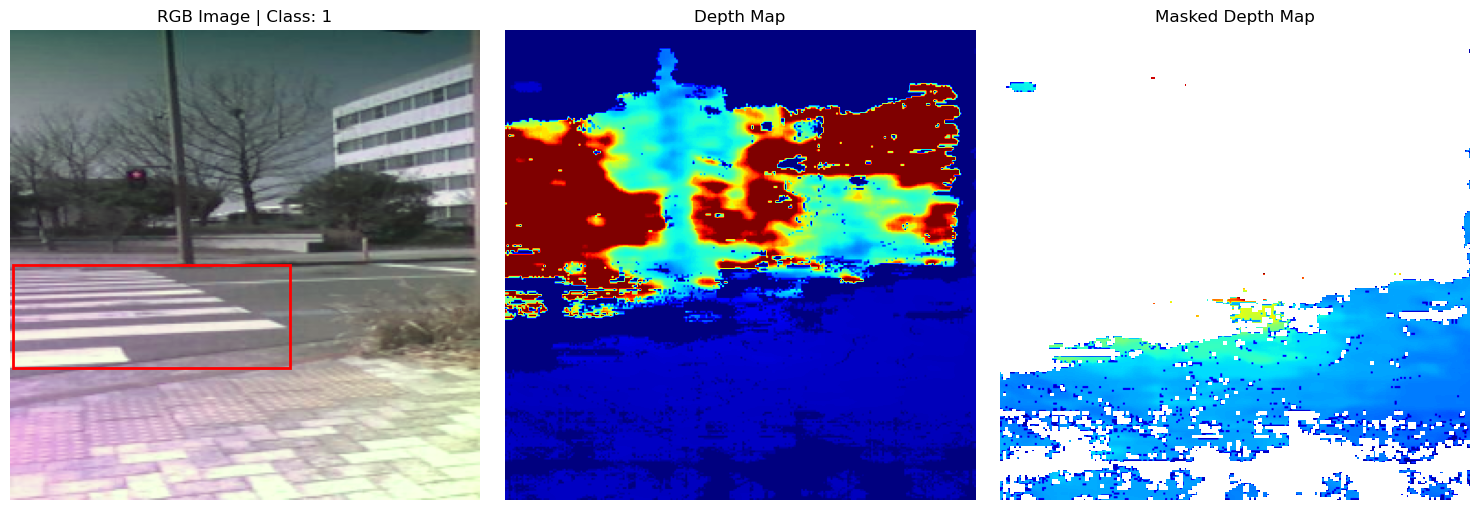

In [18]:
import matplotlib.pyplot as plt
import torch

for i in range(5):
    ret = loader.__getitem__(i)
    img, class_id, coord, depth = ret['image'], ret['class_id'], ret['coords'], ret['depth']

    fig, ax = plt.subplots(1, 3, figsize=(15, 5))

    # Konversi tensor citra RGB
    img_np = img.permute(1, 2, 0).numpy()
    h, w, _ = img_np.shape

    # 1. Visualisasi RGB dan Bounding Box
    ax[0].imshow(img_np)
    ax[0].axis('off')

    # Ekstraksi dan kalkulasi Bounding Box
    cx, cy, bw, bh = coord.numpy()

    # Validasi eksistensi objek berdasarkan class_id
    if class_id.item() > 0 and bw > 0 and bh > 0:
        # Denormalisasi koordinat ke skala piksel
        cx_pixel = cx * w
        cy_pixel = cy * h
        bw_pixel = bw * w
        bh_pixel = bh * h
        
        # Kalkulasi titik sudut kiri atas (xmin, ymin)
        xmin = cx_pixel - (bw_pixel / 2.0)
        ymin = cy_pixel - (bh_pixel / 2.0)
        
        # Penambahan patch kotak merah ke axes RGB
        rect = patches.Rectangle(
            (xmin, ymin), bw_pixel, bh_pixel, 
            linewidth=2, edgecolor='red', facecolor='none'
        )
        ax[0].add_patch(rect)
        ax[0].set_title(f"RGB Image | Class: {class_id.item()}")
    else:
        ax[0].set_title("RGB Image | Background")

    # 2. Depth map viz 
    depth_np = depth.squeeze().numpy()
    ax[1].imshow(depth_np, cmap='jet')
    ax[1].set_title("Depth Map")
    ax[1].axis('off')

    # 3. Masked depth map viz
    valid_mask = (depth_np > 0) & (depth_np < 10000)
    depth_vis = depth_np.copy().astype(float)
    depth_vis[~valid_mask] = np.nan

    if valid_mask.sum() > 0:
        vmin = depth_np[valid_mask].min()
        vmax = depth_np[valid_mask].max()
    else:
        vmin = 0.0
        vmax = 10000.0

    ax[2].imshow(depth_vis, cmap='jet', vmin=vmin, vmax=vmax)
    ax[2].set_title("Masked Depth Map")
    ax[2].axis('off')

    # Pembuatan Depth Mask
    min_depth = 0.001
    true_depth_mask = depth > min_depth
    true_depth_mask = true_depth_mask.to(torch.bool)

    plt.tight_layout()
    plt.show()

In [ ]:
masked = true_depth_mask.to(torch.int)

print(masked.shape)
print(masked.sum())

torch.Size([1, 512, 256])
tensor(71001)


In [ ]:
masked

tensor([[[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         ...,
         [0, 0, 0,  ..., 1, 1, 0],
         [0, 0, 0,  ..., 1, 0, 1],
         [0, 0, 0,  ..., 0, 0, 1]]], dtype=torch.int32)